# Day 4 – Delivery Time & Tip Prediction

## Objective

Build supervised regression models to predict delivery time or tip amount.

In this project, we will focus on **Delivery Time Prediction** and use regression techniques to predict `delivery_time_minutes` based on order, restaurant, customer, and delivery-related features.

### Learning Objectives

- Understand supervised learning and regression
- Perform feature engineering
- Split data into training and testing sets
- Build a baseline regression model
- Implement Random Forest Regression
- Implement Ridge and Lasso Regression
- Understand cross-validation and overfitting
- Evaluate models using MAE, RMSE, and R²
- Compare different regression models
- Identify important features
- Interpret the final model from a business perspective

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load datasets

customers = pd.read_csv("../data/raw/customers.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
payments = pd.read_csv("../data/raw/payments.csv")

print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Reviews:", reviews.shape)
print("Drivers:", drivers.shape)
print("Payments:", payments.shape)

Customers: (5000, 10)
Restaurants: (500, 10)
Orders: (50000, 13)
Deliveries: (50000, 11)
Reviews: (43996, 7)
Drivers: (1000, 10)
Payments: (50000, 7)


In [6]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'discount_amount', 'delivery_fee', 'tip_amount', 'payment_id', 'order_status', 'items_count', 'is_weekend', 'is_holiday']

Deliveries columns:
['delivery_id', 'order_id', 'driver_id', 'delivery_distance_km', 'weather_condition', 'traffic_condition', 'preparation_time_min', 'pickup_time', 'delivery_time', 'delivery_duration_min', 'delivery_status']


In [7]:
display(orders.head())
display(deliveries.head())

,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,tip_amount,payment_id,order_status,items_count,is_weekend,is_holiday
0,50001,13068,20124,2026-06-17 02:50:21,877.51,87.75,34.48,37.22,70001,Completed,2,False,False
1,50002,13579,20488,2025-09-04 11:42:40,112.57,22.51,98.18,5.62,70002,Completed,1,False,False
2,50003,12934,20451,2026-03-11 07:28:32,1083.58,162.54,88.20,63.72,70003,Completed,4,False,False
3,50004,11504,20078,2026-04-04 18:35:48,197.28,0.00,43.48,3.02,70004,Completed,2,True,False
4,50005,10828,20479,2025-12-17 21:38:43,1579.40,236.91,56.62,153.63,70005,Completed,3,False,False


,delivery_id,order_id,driver_id,delivery_distance_km,weather_condition,traffic_condition,preparation_time_min,pickup_time,delivery_time,delivery_duration_min,delivery_status
0,60001,50001,30395,2.10,Cloudy,Medium,17.62,2026-06-17 03:07:58.447371786,2026-06-17 03:43:00.847371786,35.04,Delivered
1,60002,50002,30730,1.07,Clear,High,25.42,2025-09-04 12:08:05.058935644,2025-09-04 12:51:20.058935644,43.25,Delivered
2,60003,50003,30977,1.49,Rain,Medium,21.69,2026-03-11 07:50:13.314857372,2026-03-11 08:20:31.314857372,30.30,Delivered
3,60004,50004,30133,2.33,Clear,Medium,32.55,2026-04-04 19:08:20.753000220,2026-04-04 19:56:01.553000220,47.68,Delivered
4,60005,50005,30304,6.18,Cloudy,High,16.64,2025-12-17 21:55:21.690232354,2025-12-17 22:44:27.690232354,49.10,Delivered


In [8]:
orders.columns.tolist()
deliveries.columns.tolist()

['delivery_id',
 'order_id',
 'driver_id',
 'delivery_distance_km',
 'weather_condition',
 'traffic_condition',
 'preparation_time_min',
 'pickup_time',
 'delivery_time',
 'delivery_duration_min',
 'delivery_status']

In [9]:
# Convert date/time columns

orders["order_timestamp"] = pd.to_datetime(orders["order_timestamp"])
deliveries["pickup_time"] = pd.to_datetime(deliveries["pickup_time"])
deliveries["delivery_time"] = pd.to_datetime(deliveries["delivery_time"])

# Merge orders with deliveries

df = orders.merge(
    deliveries,
    on="order_id",
    how="inner"
)

# Merge restaurant information

df = df.merge(
    restaurants,
    on="restaurant_id",
    how="left",
    suffixes=("", "_restaurant")
)

# Merge customer information

df = df.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("", "_customer")
)

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (50000, 41)


,order_id,customer_id,restaurant_id,order_timestamp,order_amount,discount_amount,delivery_fee,tip_amount,payment_id,order_status,...,is_chain,age,gender,city_customer,signup_date,customer_segment,avg_monthly_orders,preferred_cuisine,avg_order_value_customer,payment_preference
0,50001,13068,20124,2026-06-17 02:50:21,877.51,87.75,34.48,37.22,70001,Completed,...,False,26,Male,Delhi,2024-06-01,New,3.04,Pizza,258.19,UPI
1,50002,13579,20488,2025-09-04 11:42:40,112.57,22.51,98.18,5.62,70002,Completed,...,True,63,Male,Pune,2025-12-04,Regular,9.34,Desserts,593.66,UPI
2,50003,12934,20451,2026-03-11 07:28:32,1083.58,162.54,88.20,63.72,70003,Completed,...,False,27,Male,Mumbai,2024-01-28,Regular,8.15,Burgers,626.93,Wallet
3,50004,11504,20078,2026-04-04 18:35:48,197.28,0.00,43.48,3.02,70004,Completed,...,True,42,Male,Hyderabad,2025-07-01,Regular,7.71,Pizza,678.99,Wallet
4,50005,10828,20479,2025-12-17 21:38:43,1579.40,236.91,56.62,153.63,70005,Completed,...,False,25,Male,Chennai,2026-04-12,New,1.54,Chinese,240.01,Debit Card


In [10]:
print("Combined dataset columns:")
print(df.columns.tolist())

Combined dataset columns:
['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'discount_amount', 'delivery_fee', 'tip_amount', 'payment_id', 'order_status', 'items_count', 'is_weekend', 'is_holiday', 'delivery_id', 'driver_id', 'delivery_distance_km', 'weather_condition', 'traffic_condition', 'preparation_time_min', 'pickup_time', 'delivery_time', 'delivery_duration_min', 'delivery_status', 'restaurant_name', 'city', 'cuisine_type', 'restaurant_category', 'rating', 'avg_prep_time_min', 'avg_order_value', 'total_orders', 'is_chain', 'age', 'gender', 'city_customer', 'signup_date', 'customer_segment', 'avg_monthly_orders', 'preferred_cuisine', 'avg_order_value_customer', 'payment_preference']


In [11]:
print("Delivery duration statistics:")
print(df["delivery_duration_min"].describe())

print("\nMissing target values:")
print(df["delivery_duration_min"].isna().sum())

Delivery duration statistics:
count    50000.000000
mean        41.301786
std         12.720418
min         10.000000
25%         32.360000
50%         40.540000
75%         49.460000
max        105.350000
Name: delivery_duration_min, dtype: float64

Missing target values:
0


In [12]:
print("Weather conditions:")
print(df["weather_condition"].value_counts())

print("\nTraffic conditions:")
print(df["traffic_condition"].value_counts())

print("\nDelivery status:")
print(df["delivery_status"].value_counts())

Weather conditions:
weather_condition
Clear         24953
Cloudy        12373
Rain          10181
Heavy Rain     2493
Name: count, dtype: int64

Traffic conditions:
traffic_condition
Medium    22387
High      12627
Low       12420
Severe     2566
Name: count, dtype: int64

Delivery status:
delivery_status
Delivered    46896
Cancelled     2056
Failed        1048
Name: count, dtype: int64


In [13]:
df.shape
df.columns.tolist()
df["delivery_duration_min"].describe()

count    50000.000000
mean        41.301786
std         12.720418
min         10.000000
25%         32.360000
50%         40.540000
75%         49.460000
max        105.350000
Name: delivery_duration_min, dtype: float64

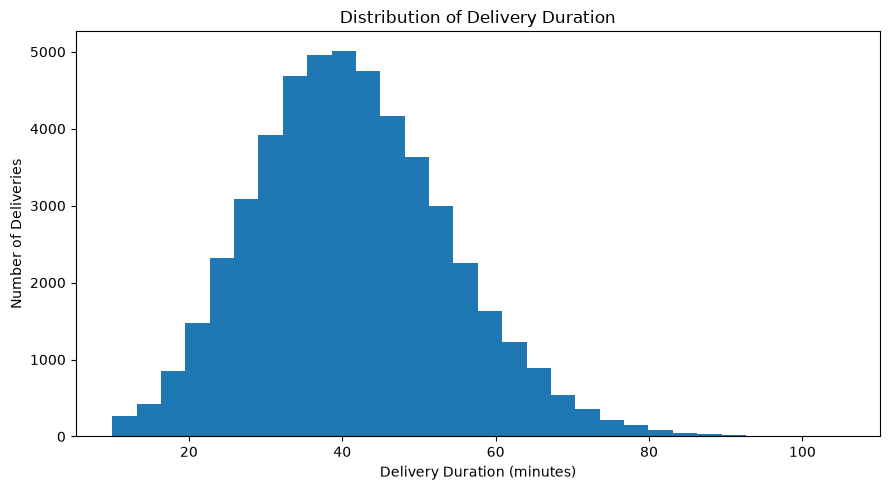

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["delivery_duration_min"],
    bins=30
)

plt.title("Distribution of Delivery Duration")
plt.xlabel("Delivery Duration (minutes)")
plt.ylabel("Number of Deliveries")

plt.tight_layout()
plt.show()

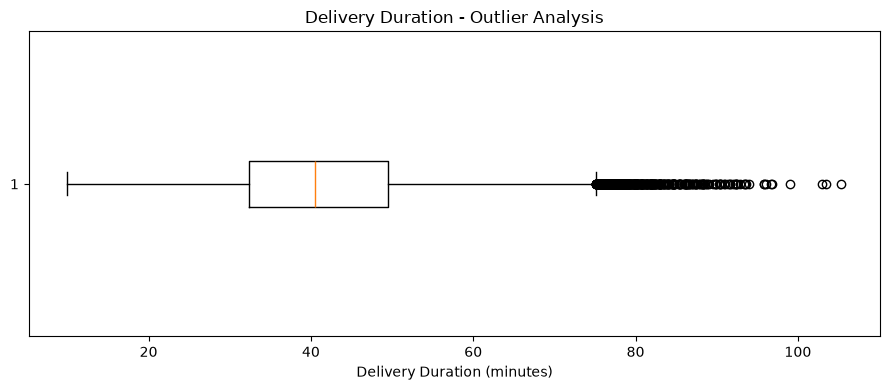

In [15]:
plt.figure(figsize=(9, 4))

plt.boxplot(
    df["delivery_duration_min"],
    vert=False
)

plt.title("Delivery Duration - Outlier Analysis")
plt.xlabel("Delivery Duration (minutes)")

plt.tight_layout()
plt.show()

In [16]:
print("Delivery Duration Statistics")
print("=" * 35)

print(f"Mean   : {df['delivery_duration_min'].mean():.2f} minutes")
print(f"Median : {df['delivery_duration_min'].median():.2f} minutes")
print(f"Std    : {df['delivery_duration_min'].std():.2f} minutes")
print(f"Min    : {df['delivery_duration_min'].min():.2f} minutes")
print(f"Max    : {df['delivery_duration_min'].max():.2f} minutes")

Delivery Duration Statistics
Mean   : 41.30 minutes
Median : 40.54 minutes
Std    : 12.72 minutes
Min    : 10.00 minutes
Max    : 105.35 minutes


In [17]:
# Select numerical columns

numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation = (
    df[numeric_cols]
    .corr()["delivery_duration_min"]
    .sort_values(ascending=False)
)

print("Correlation with Delivery Duration:")
print(correlation)

Correlation with Delivery Duration:
delivery_duration_min       1.000000
preparation_time_min        0.578927
delivery_distance_km        0.543894
avg_prep_time_min           0.530641
restaurant_id               0.011320
avg_order_value_customer    0.011027
avg_monthly_orders          0.008008
customer_id                 0.007352
order_id                    0.001663
payment_id                  0.001663
delivery_id                 0.001663
avg_order_value             0.000044
tip_amount                 -0.000796
delivery_fee               -0.002695
rating                     -0.002974
age                        -0.003553
driver_id                  -0.004242
discount_amount            -0.004441
order_amount               -0.005114
items_count                -0.008523
total_orders               -0.035849
Name: delivery_duration_min, dtype: float64


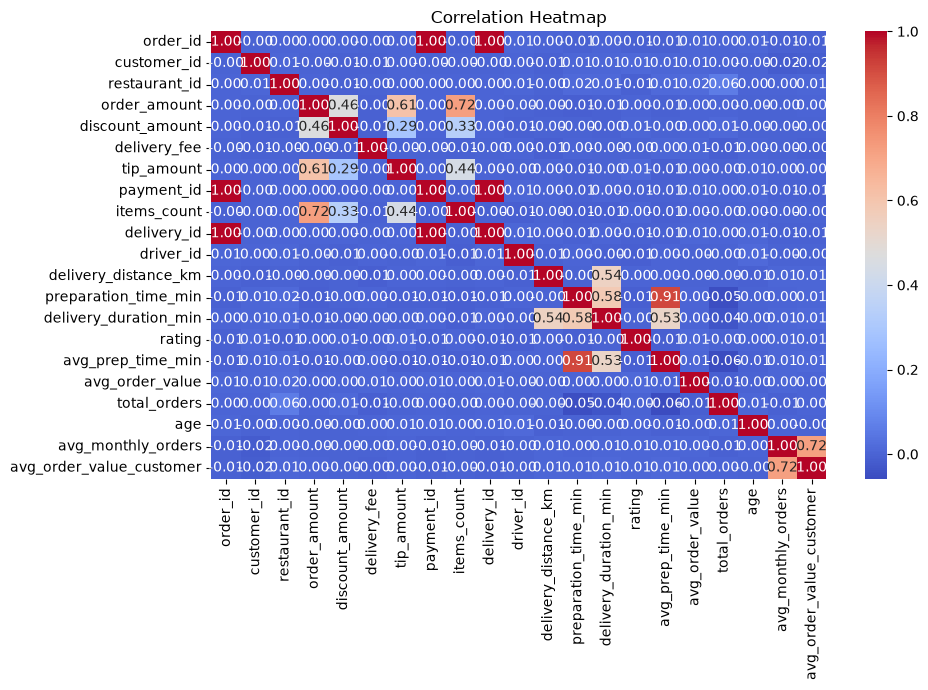

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

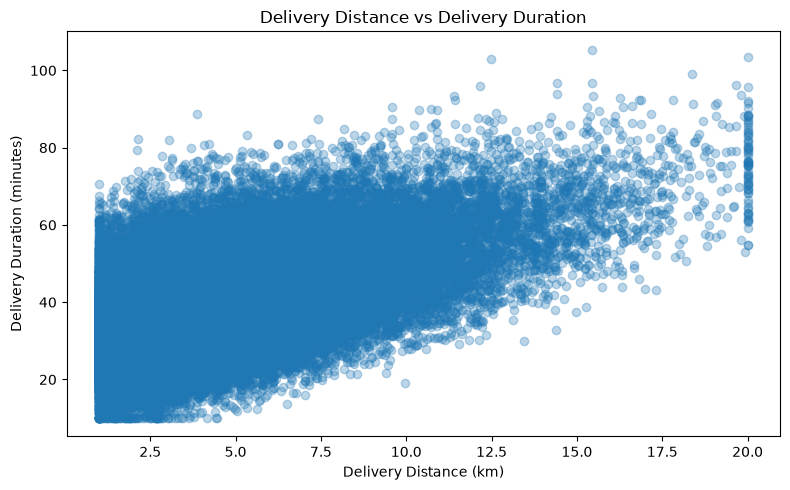

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["delivery_distance_km"],
    df["delivery_duration_min"],
    alpha=0.3
)

plt.title("Delivery Distance vs Delivery Duration")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Duration (minutes)")

plt.tight_layout()
plt.show()

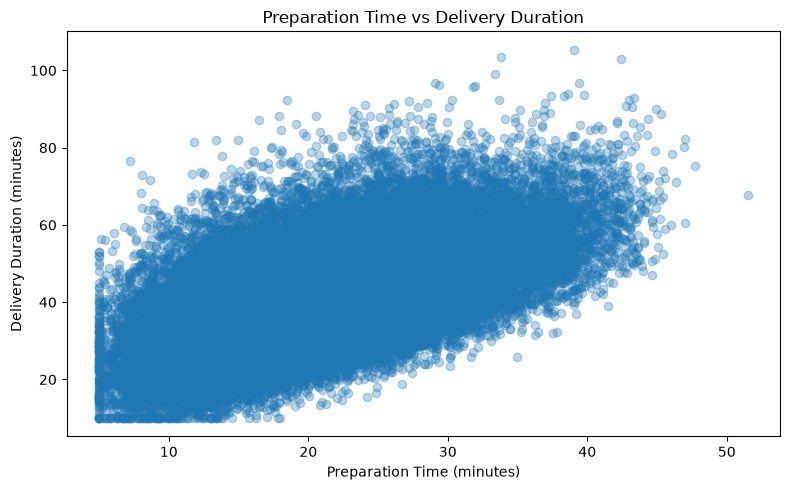

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["preparation_time_min"],
    df["delivery_duration_min"],
    alpha=0.3
)

plt.title("Preparation Time vs Delivery Duration")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Duration (minutes)")

plt.tight_layout()
plt.show()

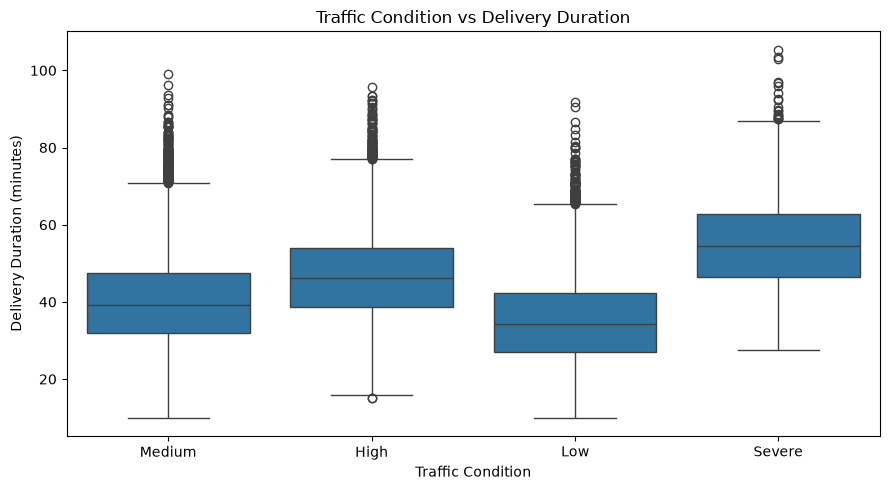

In [21]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="traffic_condition",
    y="delivery_duration_min"
)

plt.title("Traffic Condition vs Delivery Duration")
plt.xlabel("Traffic Condition")
plt.ylabel("Delivery Duration (minutes)")

plt.tight_layout()
plt.show()

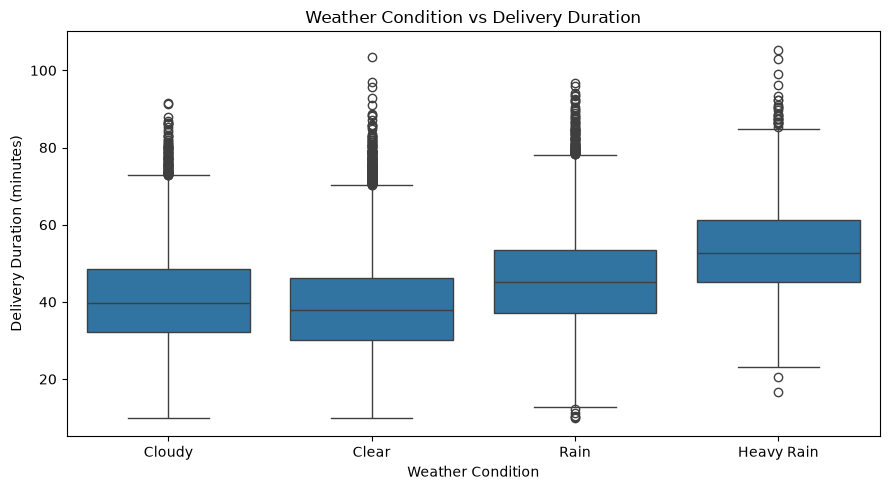

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="weather_condition",
    y="delivery_duration_min"
)

plt.title("Weather Condition vs Delivery Duration")
plt.xlabel("Weather Condition")
plt.ylabel("Delivery Duration (minutes)")

plt.tight_layout()
plt.show()

In [23]:
# Keep only successfully delivered orders

model_df = df[
    df["delivery_status"] == "Delivered"
].copy()

print("Original dataset:", df.shape)
print("Delivered dataset:", model_df.shape)

Original dataset: (50000, 41)
Delivered dataset: (46896, 41)


In [24]:
# Extract time-based features from order timestamp

model_df["order_hour"] = model_df["order_timestamp"].dt.hour

model_df["day_of_week"] = model_df["order_timestamp"].dt.dayofweek

model_df["is_weekend"] = model_df["order_timestamp"].dt.dayofweek.isin(
    [5, 6]
).astype(int)

print(
    model_df[
        [
            "order_timestamp",
            "order_hour",
            "day_of_week",
            "is_weekend"
        ]
    ].head()
)

      order_timestamp  order_hour  day_of_week  is_weekend
0 2026-06-17 02:50:21           2            2           0
1 2025-09-04 11:42:40          11            3           0
2 2026-03-11 07:28:32           7            2           0
3 2026-04-04 18:35:48          18            5           1
4 2025-12-17 21:38:43          21            2           0


In [25]:
def get_time_of_day(hour):

    if 6 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 22:
        return "Evening"

    else:
        return "Night"


model_df["time_of_day"] = model_df["order_hour"].apply(
    get_time_of_day
)

print(model_df["time_of_day"].value_counts())

time_of_day
Night        15680
Morning      11576
Evening       9859
Afternoon     9781
Name: count, dtype: int64


In [26]:
features = [
    "delivery_distance_km",
    "order_amount",
    "items_count",
    "preparation_time_min",
    "rating",
    "order_hour",
    "day_of_week",
    "is_weekend",
    "weather_condition",
    "traffic_condition",
    "time_of_day"
]

target = "delivery_duration_min"

model_data = model_df[
    features + [target]
].copy()

print("Modeling dataset shape:", model_data.shape)
display(model_data.head())

Modeling dataset shape: (46896, 12)


,delivery_distance_km,order_amount,items_count,preparation_time_min,rating,order_hour,day_of_week,is_weekend,weather_condition,traffic_condition,time_of_day,delivery_duration_min
0,2.10,877.51,2,17.62,4.22,2,2,0,Cloudy,Medium,Night,35.04
1,1.07,112.57,1,25.42,4.99,11,3,0,Clear,High,Morning,43.25
2,1.49,1083.58,4,21.69,4.62,7,2,0,Rain,Medium,Morning,30.30
3,2.33,197.28,2,32.55,4.17,18,5,1,Clear,Medium,Evening,47.68
4,6.18,1579.40,3,16.64,4.18,21,2,0,Cloudy,High,Evening,49.10


In [27]:
print("Missing values:")
print(model_data.isnull().sum())

print("\nDuplicate rows:", model_data.duplicated().sum())


Missing values:
delivery_distance_km     0
order_amount             0
items_count              0
preparation_time_min     0
rating                   0
order_hour               0
day_of_week              0
is_weekend               0
weather_condition        0
traffic_condition        0
time_of_day              0
delivery_duration_min    0
dtype: int64

Duplicate rows: 0


In [28]:
model_data.shape
model_data.isnull().sum()

delivery_distance_km     0
order_amount             0
items_count              0
preparation_time_min     0
rating                   0
order_hour               0
day_of_week              0
is_weekend               0
weather_condition        0
traffic_condition        0
time_of_day              0
delivery_duration_min    0
dtype: int64

In [29]:
# One-hot encode categorical variables

model_encoded = pd.get_dummies(
    model_data,
    columns=[
        "weather_condition",
        "traffic_condition",
        "time_of_day"
    ],
    drop_first=True
)

print("Encoded dataset shape:", model_encoded.shape)

display(model_encoded.head())

Encoded dataset shape: (46896, 18)


,delivery_distance_km,order_amount,items_count,preparation_time_min,rating,order_hour,day_of_week,is_weekend,delivery_duration_min,weather_condition_Cloudy,weather_condition_Heavy Rain,weather_condition_Rain,traffic_condition_Low,traffic_condition_Medium,traffic_condition_Severe,time_of_day_Evening,time_of_day_Morning,time_of_day_Night
0,2.10,877.51,2,17.62,4.22,2,2,0,35.04,True,False,False,False,True,False,False,False,True
1,1.07,112.57,1,25.42,4.99,11,3,0,43.25,False,False,False,False,False,False,False,True,False
2,1.49,1083.58,4,21.69,4.62,7,2,0,30.30,False,False,True,False,True,False,False,True,False
3,2.33,197.28,2,32.55,4.17,18,5,1,47.68,False,False,False,False,True,False,True,False,False
4,6.18,1579.40,3,16.64,4.18,21,2,0,49.10,True,False,False,False,False,False,True,False,False


In [30]:
# Separate features and target

X = model_encoded.drop(
    columns=["delivery_duration_min"]
)

y = model_encoded["delivery_duration_min"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (46896, 17)
Target shape: (46896,)


In [31]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (37516, 17)
Testing data: (9380, 17)


In [32]:
# Baseline Linear Regression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

print("Baseline Linear Regression completed!")

Baseline Linear Regression completed!


In [33]:
# Evaluate Linear Regression

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")
print("=" * 35)
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Performance
MAE  : 3.19
RMSE : 3.97
R²   : 0.8992


In [34]:
# Random Forest Regression

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

print("Random Forest Regression completed!")

Random Forest Regression completed!


In [35]:
# Evaluate Random Forest

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Performance")
print("=" * 35)
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
MAE  : 3.40
RMSE : 4.24
R²   : 0.8852


In [36]:
# Compare Linear Regression and Random Forest

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,3.187982,3.970435,0.899194
1,Random Forest,3.402696,4.236611,0.885225


In [37]:
# Feature scaling for Ridge and Lasso

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [38]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression completed!")

Ridge Regression completed!


In [39]:
# Evaluate Ridge Regression

mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge
    )
)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("Ridge Regression Performance")
print("=" * 35)
print(f"MAE  : {mae_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression Performance
MAE  : 3.19
RMSE : 3.97
R²   : 0.8992


In [40]:
# Lasso Regression

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

print("Lasso Regression completed!")

Lasso Regression completed!


In [41]:
# Evaluate Lasso Regression

mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

rmse_lasso = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lasso
    )
)

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("Lasso Regression Performance")
print("=" * 35)
print(f"MAE  : {mae_lasso:.2f}")
print(f"RMSE : {rmse_lasso:.2f}")
print(f"R²   : {r2_lasso:.4f}")

Lasso Regression Performance
MAE  : 3.19
RMSE : 3.97
R²   : 0.8992


In [42]:
# Update model comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Ridge",
        "Lasso"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_ridge,
        mae_lasso
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_ridge,
        rmse_lasso
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_ridge,
        r2_lasso
    ]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,3.187982,3.970435,0.899194
1,Random Forest,3.402696,4.236611,0.885225
2,Ridge,3.187980,3.970432,0.899194
3,Lasso,3.187644,3.969839,0.899224


In [44]:
from sklearn.pipeline import Pipeline

models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    mae_scores = -scores

    cv_results.append({
        "Model": name,
        "Mean CV MAE": mae_scores.mean(),
        "Std CV MAE": mae_scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(
    cv_df.sort_values("Mean CV MAE")
)

,Model,Mean CV MAE,Std CV MAE
1,Ridge,3.177952,0.022936
0,Linear Regression,3.177953,0.022938
2,Lasso,3.177981,0.023116
3,Random Forest,3.399450,0.034222


In [45]:
# Lasso feature coefficients

lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coefficients["Absolute_Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

lasso_coefficients = lasso_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(lasso_coefficients)

,Feature,Coefficient,Absolute_Coefficient
3,preparation_time_min,7.412251,7.412251
0,delivery_distance_km,6.982940,6.982940
11,traffic_condition_Low,-5.193510,5.193510
12,traffic_condition_Medium,-3.465761,3.465761
9,weather_condition_Heavy Rain,3.263537,3.263537
10,weather_condition_Rain,2.828982,2.828982
13,traffic_condition_Severe,1.747037,1.747037
8,weather_condition_Cloudy,0.833710,0.833710
1,order_amount,0.052757,0.052757
2,items_count,-0.032834,0.032834


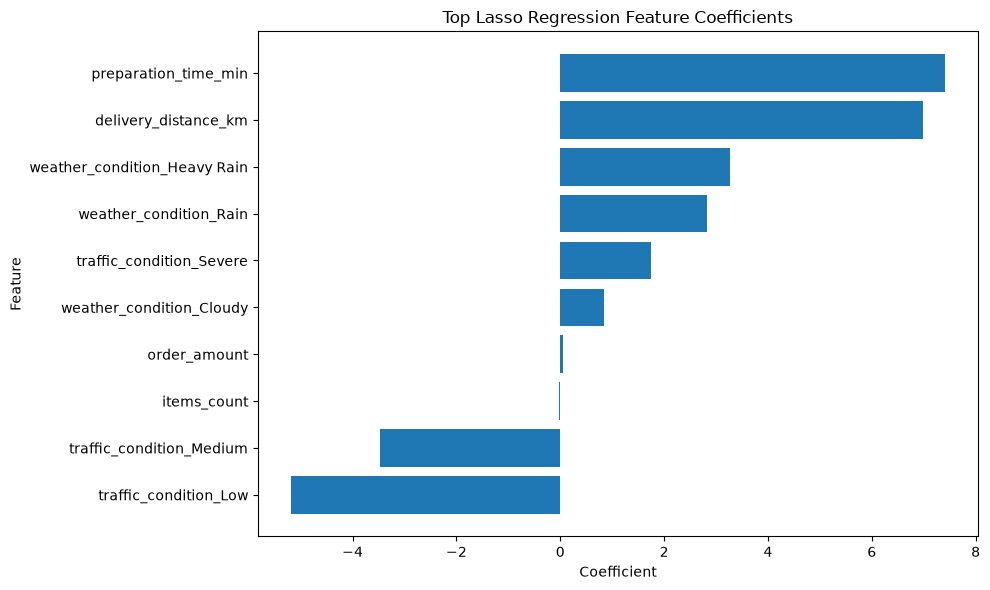

In [46]:
# Top feature coefficients

top_coefficients = lasso_coefficients.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.title("Top Lasso Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

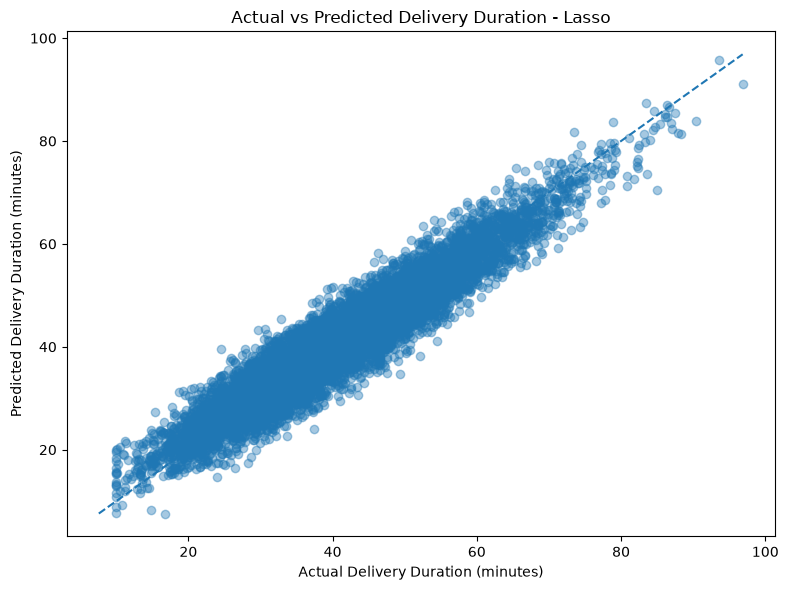

In [47]:
# Actual vs Predicted Delivery Duration

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_lasso.min())
max_value = max(y_test.max(), y_pred_lasso.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Duration (minutes)")
plt.ylabel("Predicted Delivery Duration (minutes)")
plt.title("Actual vs Predicted Delivery Duration - Lasso")

plt.tight_layout()
plt.show()

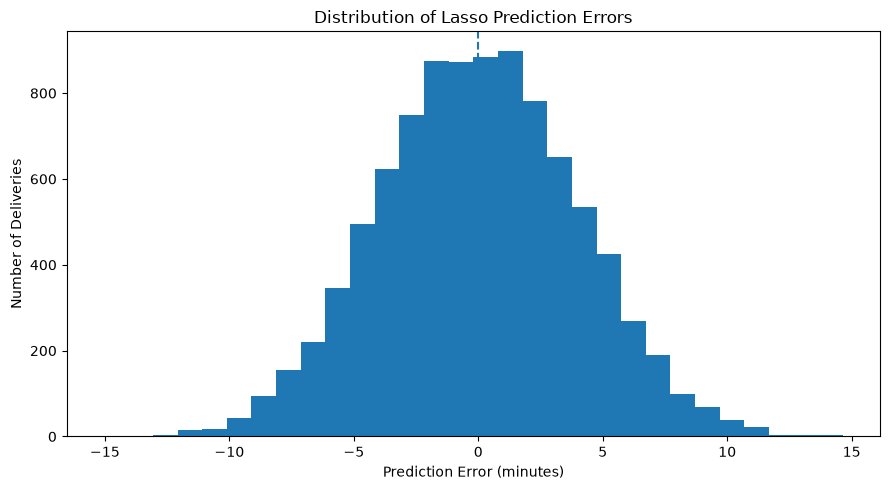

In [48]:
# Prediction residuals

residuals = y_test - y_pred_lasso

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Lasso Prediction Errors")

plt.tight_layout()
plt.show()

In [49]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Ridge",
        "Lasso"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_ridge,
        mae_lasso
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_ridge,
        rmse_lasso
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_ridge,
        r2_lasso
    ]
})

final_comparison = final_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

display(final_comparison)

,Model,MAE,RMSE,R2
0,Lasso,3.187644,3.969839,0.899224
1,Ridge,3.187980,3.970432,0.899194
2,Linear Regression,3.187982,3.970435,0.899194
3,Random Forest,3.402696,4.236611,0.885225


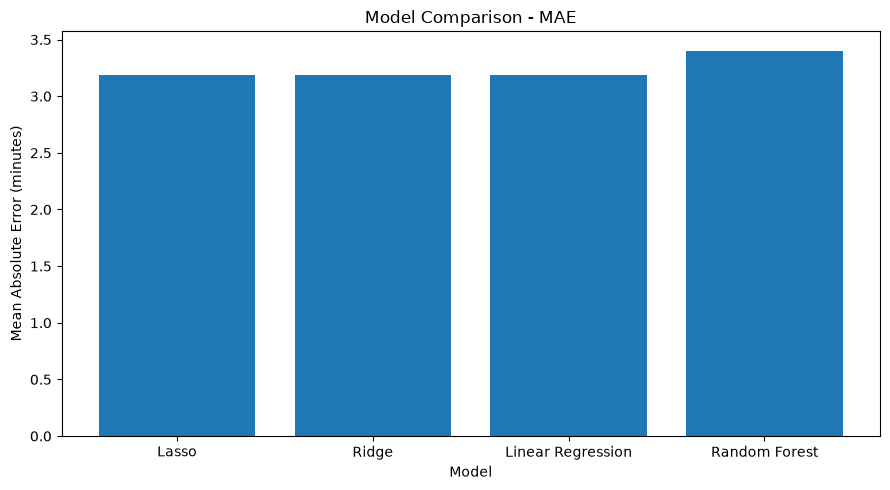

In [50]:
# Compare MAE across models

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (minutes)")

plt.tight_layout()
plt.show()

In [51]:
# Identify the best model based on MAE

best_model = final_comparison.loc[
    final_comparison["MAE"].idxmin()
]

print("Best Model Based on MAE")
print("=" * 35)
print(f"Model : {best_model['Model']}")
print(f"MAE   : {best_model['MAE']:.4f}")
print(f"RMSE  : {best_model['RMSE']:.4f}")
print(f"R²    : {best_model['R2']:.4f}")

Best Model Based on MAE
Model : Lasso
MAE   : 3.1876
RMSE  : 3.9698
R²    : 0.8992
